## Peramalan kadar NO2 di  daerah Lamongan Jawa Timur

Kita install terlebih dahulu openoneo:

In [2]:
pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.8 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


Lalu tuliskan code dibawah:
setelah berhasil di run nantiKalian tinggal klik link authentikasi lalu login menggunakan akun “copernicus” kalian.

In [3]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()


Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=BSTM-OFTS 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


In [7]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [112.42502397290974, -7.108386614808737],
            [112.43425883020518, -7.108386787952824],
            [112.43425862773017, -7.116596211376901],
            [112.4252162, -7.1167235],
            [112.42502397290974, -7.108386614808737]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2025-10-01"],
    spatial_extent={
        "west": 112.42502397290974,
        "south": -7.1167235,
        "east": 112.43425883020518,
        "north": -7.108386614808737
    },
    bands=["NO2"],
)

# Now aggregate by day to avoid having multiple data per day
s5p_no2_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Now create a spatial aggregation to generate mean timeseries data
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)
job = s5post.execute_batch(
    title="NO2 in Lamongan",
    outputfile="NO2Lamongan.nc"
)

0:00:00 Job 'j-2606030154384690a38c83c92b09eee9': send 'start'
0:00:08 Job 'j-2606030154384690a38c83c92b09eee9': queued (progress 0%)
0:00:13 Job 'j-2606030154384690a38c83c92b09eee9': queued (progress 0%)
0:00:19 Job 'j-2606030154384690a38c83c92b09eee9': queued (progress 0%)
0:00:27 Job 'j-2606030154384690a38c83c92b09eee9': queued (progress 0%)
0:00:37 Job 'j-2606030154384690a38c83c92b09eee9': running (progress N/A)
0:00:50 Job 'j-2606030154384690a38c83c92b09eee9': running (progress N/A)
0:01:05 Job 'j-2606030154384690a38c83c92b09eee9': running (progress N/A)
0:01:25 Job 'j-2606030154384690a38c83c92b09eee9': running (progress N/A)
0:01:49 Job 'j-2606030154384690a38c83c92b09eee9': running (progress N/A)
0:02:19 Job 'j-2606030154384690a38c83c92b09eee9': running (progress N/A)
0:02:57 Job 'j-2606030154384690a38c83c92b09eee9': running (progress N/A)
0:03:43 Job 'j-2606030154384690a38c83c92b09eee9': running (progress N/A)
0:04:42 Job 'j-2606030154384690a38c83c92b09eee9': running (progress N

Code diatas memerlukan titik koordinasi area yang akan diambil data NO2
-nya, untuk mengambil titik koordinasi kaian kunjungi webiste https://geojson.io/#map=14.8/-7.04732/112.69463 . Didalam website tersebut kalian akan memilih daerah dengan cara memberi shape kotak didaerah yang ingin kalian ambil datanya.

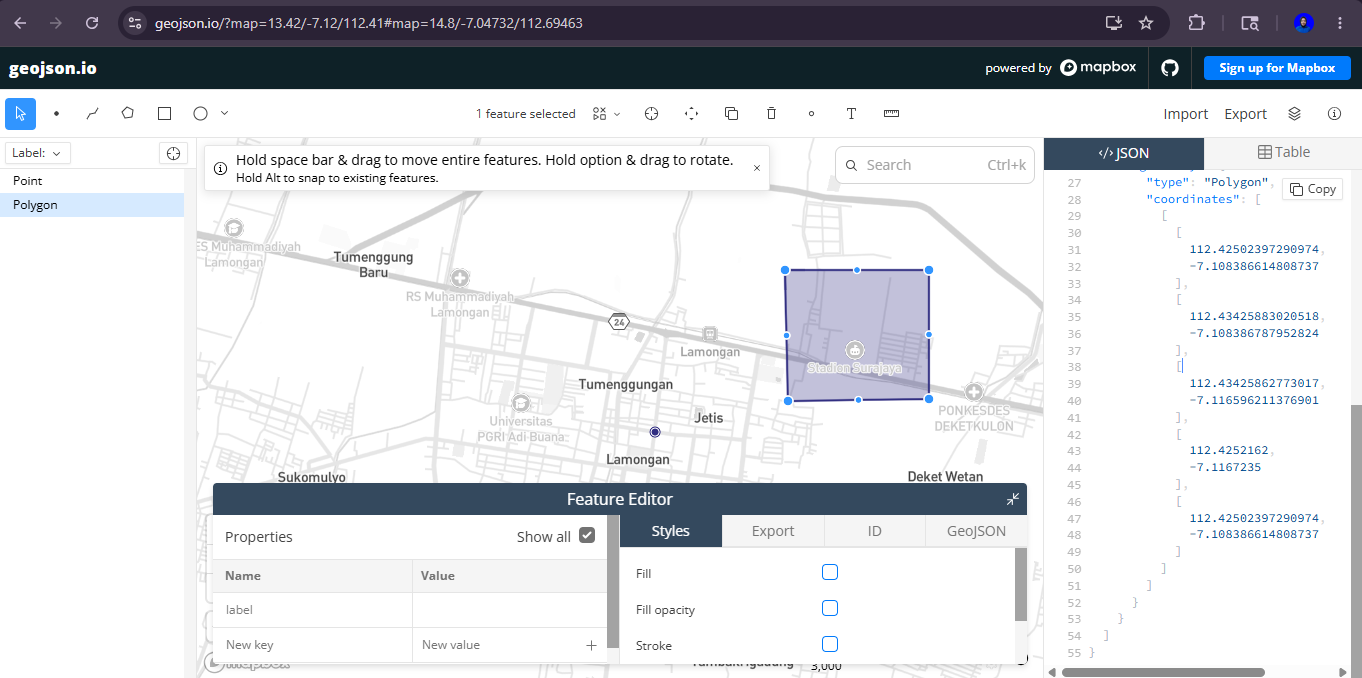


Di panel sebelah kanan terdapat data JSON yang berupa koordinat daerah yang kalian pilih, kalian salin terus sesuaikan dengan code diatas di bagian variabel “aoi” dan spatial_extent.

Lalu kalian tambahkan baris code dibawah untuk memulai pengambilan data:

In [ ]:
job = s5post.execute_batch(
    title="NO2 in Lamongan",
    outputfile="NO2Lamongan.nc"
)

Code di atas punyaku udah aku jadiin satu dengan datanya dan hasilnya sudah ada di atas dan setelah itu masukkin openEO.nc dibawah ini

In [10]:
from google.colab import files

uploaded = files.upload()

Saving openEO.nc to openEO.nc


Jika setelah kita masukkin kita cek jika hasilnya config, openEO, sample data artinya file nya sudah masuk seperti dibawah ini:

In [11]:
import os

print(os.listdir())

['.config', 'openEO.nc', 'sample_data']


#2. Preprocessing Data

a. Membaca File NetCDF

Data hasil unduhan dari OpenEO berbentuk file NetCDF (.nc). File tersebut dibaca menggunakan library netCDF4 untuk mengambil variabel waktu (t) dan konsentrasi NO₂ (NO2).

In [26]:
import netCDF4

file_path = "openEO.nc"
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("📦 Variabel dalam file:")
print(ds.variables.keys())

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time

# Tampilkan struktur data NO2
print(type(no2))

print(len(no2))
# banyaknya data record

print(len(no2[0]))
# panjang data perbaris

print(len(no2[0][0]))
# panjang perdata

print(no2[0][0][0])
# nilai pertama

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
725
1
1
0.00013400802


Berdasarkan hasil output tersebut, file memiliki lima variabel yaitu waktu (t), koordinat spasial (x dan y), sistem koordinat (crs), dan konsentrasi NO₂ (NO2).

B. 10 data pertama:

In [27]:
print("Contoh data pertama:")

for i in range(10):
    print(no2[i])

Contoh data pertama:
[[0.00013400801981333643]]
[[0.00010568308061920106]]
[[0.00010066835238831118]]
[[3.208193083992228e-05]]
[[0.00015121787146199495]]
[[0.0001702599402051419]]
[[8.525193698005751e-05]]
[[1.8034248569165356e-05]]
[[2.722386852838099e-05]]
[[--]]


C. Mengambil Data Tanggal dan Nilai NO₂

Setelah data berhasil dibaca dari file NetCDF, langkah berikutnya adalah mengambil informasi tanggal dan nilai konsentrasi NO₂ untuk setiap record. Proses ini dilakukan menggunakan perulangan (for) yang membaca seluruh data berdasarkan jumlah record yang tersedia.

In [ ]:
import pandas as pd
import numpy as np

new_dates = []
new_no2 = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)

    # langsung ambil nilai NO2
    new_no2.append(float(no2[i,0,0]))

DataFrame disimpan dalam format CSV dengan nama NO2_Lamongan_timeseries.csv agar lebih mudah digunakan pada tahap analisis berikutnya. Untuk memastikan data telah tersusun dengan benar, dilakukan pengecekan menggunakan df.head() untuk melihat lima data pertama dan df.info() untuk melihat struktur dataset, jumlah data, serta tipe data pada setiap kolom. Dataset yang dihasilkan kemudian siap digunakan untuk proses preprocessing dan pemodelan.

In [30]:
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

df.to_csv("NO2_Lamongan_timeseries.csv", index=False)

print(df.head())
print(df.info())

         date       NO2
0  2023-10-01  0.000134
1  2023-10-02  0.000106
2  2023-10-03  0.000101
3  2023-10-04  0.000032
4  2023-10-05  0.000151
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 725 entries, 0 to 724
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    725 non-null    object 
 1   NO2     382 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.5+ KB
None


In [13]:
# Ambil data NO2
no2 = ds.variables["NO2"][:]

# Ambil data waktu
time = ds.variables["t"][:]

# Konversi waktu ke tanggal
time_units = ds.variables["t"].units
dates = netCDF4.num2date(time, units=time_units)

print(type(no2))
print("Shape:", no2.shape)
print("Jumlah data:", len(no2))
print("Nilai pertama:", no2[0][0][0])

<class 'numpy.ma.MaskedArray'>
Shape: (725, 1, 1)
Jumlah data: 725
Nilai pertama: 0.00013400802


In [14]:
import pandas as pd

new_dates = []
new_no2 = []

for i in range(len(dates)):
    new_dates.append(dates[i].strftime('%Y-%m-%d'))
    new_no2.append(float(no2[i, 0, 0]))

df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

print(df.head())
print(df.info())

         date       NO2
0  2023-10-01  0.000134
1  2023-10-02  0.000106
2  2023-10-03  0.000101
3  2023-10-04  0.000032
4  2023-10-05  0.000151
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 725 entries, 0 to 724
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    725 non-null    object 
 1   NO2     382 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.5+ KB
None


/tmp/ipykernel_339/3601053479.py:8: UserWarning: Warning: converting a masked element to nan.
  new_no2.append(float(no2[i, 0, 0]))


Di bawah ini code csv di simpan:

In [15]:
df.to_csv("NO2_Lamongan_timeseries.csv", index=False)

print("CSV berhasil disimpan")

CSV berhasil disimpan


In [16]:
import pandas as pd

df['date'] = pd.to_datetime(df['date'])

full_range = pd.date_range(
    start="2023-10-01",
    end="2025-09-30",
    freq="D"
)

missing_dates = full_range.difference(df['date'])

print("Jumlah hari missing:", len(missing_dates))
print(missing_dates)

Jumlah hari missing: 6
DatetimeIndex(['2023-11-11', '2024-01-01', '2024-03-23', '2024-08-12',
               '2025-01-30', '2025-01-31'],
              dtype='datetime64[ns]', freq=None)


In [17]:
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

df['NO2'] = df['NO2'].interpolate(method='time')

df['NO2'] = (
    df['NO2']
    .fillna(method='bfill')
    .fillna(method='ffill')
)

df.to_csv("NO2_Lamongan_interpolated.csv")

print(df.head())
print(df.info())

                 NO2
date                
2023-10-01  0.000134
2023-10-02  0.000106
2023-10-03  0.000101
2023-10-04  0.000032
2023-10-05  0.000151
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 731 entries, 2023-10-01 to 2025-09-30
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NO2     731 non-null    float64
dtypes: float64(1)
memory usage: 27.6 KB
None


/tmp/ipykernel_339/1545265560.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='bfill')
/tmp/ipykernel_339/1545265560.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='ffill')


In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(
    df[['NO2']]
)

print(df.head())

                 NO2  NO2_scaled
date                            
2023-10-01  0.000134    0.431455
2023-10-02  0.000106    0.339727
2023-10-03  0.000101    0.323487
2023-10-04  0.000032    0.101376
2023-10-05  0.000151    0.487187


In [19]:
import pandas as pd

def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()

    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    df_supervised['NO2(t)'] = data

    df_supervised.dropna(inplace=True)

    return df_supervised

supervised_df = create_supervised(
    df['NO2_scaled'],
    n_lag=4
)

print(supervised_df.head())
print(supervised_df.shape)

            NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
date                                                        
2023-10-05  0.431455  0.339727  0.323487  0.101376  0.487187
2023-10-06  0.339727  0.323487  0.101376  0.487187  0.548853
2023-10-07  0.323487  0.101376  0.487187  0.548853  0.273562
2023-10-08  0.101376  0.487187  0.548853  0.273562  0.055884
2023-10-09  0.487187  0.548853  0.273562  0.055884  0.085643
(727, 5)


In [40]:
df["lag1"] = df["NO2"].shift(1)
df["lag2"] = df["NO2"].shift(2)
df["lag3"] = df["NO2"].shift(3)
df["lag4"] = df["NO2"].shift(4)

supervised_df4 = df.dropna()

X = supervised_df4.drop(columns=['NO2']).values
y = supervised_df4['NO2'].values

# Penjelasan RMSE, MAE, dan MAPE

Untuk mengevaluasi kinerja model KNN dalam memprediksi nilai NO₂ berdasarkan 4 hari sebelumnya, digunakan tiga metrik utama yaitu MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), dan MAPE (Mean Absolute Percentage Error).

MAE menunjukkan rata-rata selisih absolut antara nilai aktual dan hasil prediksi. Semakin kecil MAE, maka semakin dekat hasil prediksi terhadap nilai sebenarnya.

RMSE mengukur besar kesalahan prediksi dengan memberikan penalti lebih besar pada kesalahan yang besar. RMSE sangat berguna untuk melihat apakah model sering melakukan kesalahan besar dalam prediksi.

MAPE menunjukkan tingkat kesalahan dalam bentuk persentase terhadap nilai aktual, sehingga lebih mudah dipahami karena menggunakan satuan persen.

In [42]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ======================
# 1. LOAD DATA (kalau belum load)
# ======================
# df = pd.read_csv("data_no2.csv")

# ======================
# 2. BUAT FITUR 4 HARI SEBELUMNYA
# ======================
df["lag1"] = df["NO2"].shift(1)
df["lag2"] = df["NO2"].shift(2)
df["lag3"] = df["NO2"].shift(3)
df["lag4"] = df["NO2"].shift(4)

df = df.dropna()

# ======================
# 3. SPLIT DATA
# ======================
X = df[["lag1", "lag2", "lag3", "lag4"]].values
y = df["NO2"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# ======================
# 4. MODEL KNN
# ======================
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# ======================
# 5. EVALUASI
# ======================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

# ======================
# 6. OUTPUT
# ======================
print("=== KNN REGRESSION - 4 HARI SEBELUMNYA ===")
print(f"Train Size : {len(X_train)}")
print(f"Test Size  : {len(X_test)}")

print("\n=== METRICS ===")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

=== KNN REGRESSION - 4 HARI SEBELUMNYA ===
Train Size : 581
Test Size  : 146

=== METRICS ===
MAE  : 0.000023
RMSE : 0.000033
MAPE : 41.74%
R²   : 0.0863


# Penjelasan Grafik KNN (4 Hari Sebelumnya)

Grafik yang dihasilkan menunjukkan perbandingan antara nilai NO₂ aktual (Actual) dan nilai hasil prediksi model KNN (Predicted) berdasarkan 4 hari data sebelumnya (lag 1–lag 4).

Pada grafik:

Garis biru (Actual) menunjukkan nilai NO₂ asli dari data uji.
Garis oranye (Predicted) menunjukkan hasil prediksi model KNN.
Sumbu X menunjukkan urutan data uji (sample index).
Sumbu Y menunjukkan konsentrasi NO₂.
🔎 Interpretasi:

Jika garis prediksi (oranye) mengikuti pola garis aktual (biru), maka model dianggap cukup baik.
Namun jika banyak jarak/jauh berbeda, berarti model masih kurang akurat dalam menangkap pola data

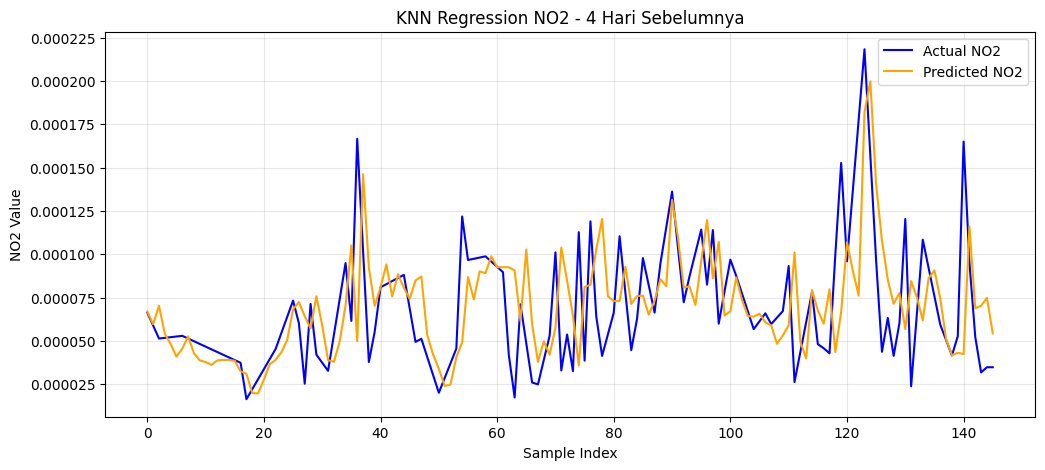

In [43]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,5))

x = np.arange(len(y_test))

# Actual
plt.plot(x, y_test, label="Actual NO2", color="blue")

# Predicted
plt.plot(x, y_pred, label="Predicted NO2", color="orange")

plt.title("KNN Regression NO2 - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [23]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = supervised_df10.drop(columns=['NO2(t)']).values
y = supervised_df10['NO2(t)'].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== KNN - 10 Hari Sebelumnya ===")
print(f"Train Size: {len(X_train)}")
print(f"Test Size: {len(X_test)}")
print(f"RMSE: {rmse:.6f}")
print(f"R² Score: {r2:.4f}")

=== KNN - 10 Hari Sebelumnya ===
Train Size: 576
Test Size: 145
RMSE: 0.112047
R² Score: 0.0125


# Untuk model KNN - 10 Hari Sebelumnya:

Berdasarkan hasil pengujian model KNN Regression dengan menggunakan 10 hari sebelumnya sebagai fitur, diperoleh jumlah data latih (train) sebanyak 576 data dan data uji (test) sebanyak 145 data. Hasil evaluasi menunjukkan nilai RMSE sebesar 0,112047 dan R² Score sebesar 0,0125. Nilai RMSE yang relatif kecil menunjukkan bahwa rata-rata kesalahan prediksi model tidak terlalu besar. Namun, nilai R² yang sangat mendekati nol menunjukkan bahwa model hanya mampu menjelaskan sebagian kecil variasi data NO₂. Hal ini mengindikasikan bahwa penggunaan 10 hari sebelumnya sebagai fitur belum mampu memberikan pola yang kuat untuk memprediksi konsentrasi NO₂ pada hari berikutnya. Kemungkinan terdapat faktor lain yang memengaruhi perubahan konsentrasi NO₂ sehingga hubungan antar data historis tidak terlalu kuat.

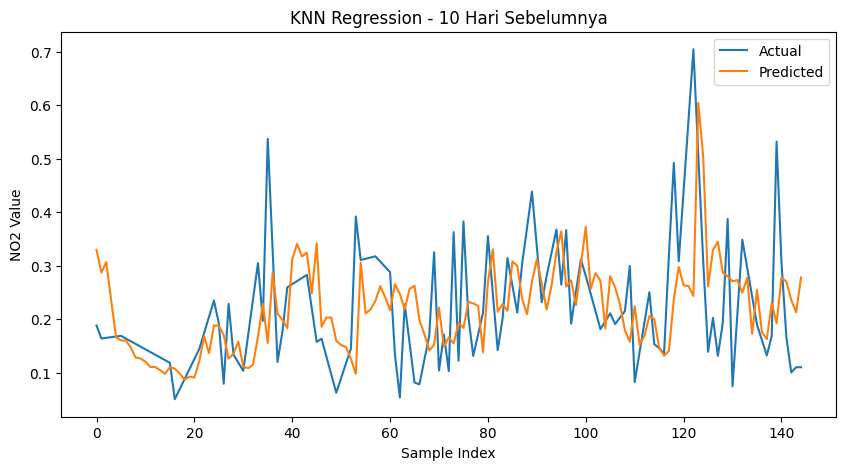

In [24]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))

plt.plot(
    np.arange(len(y_test)),
    y_test,
    label="Actual"
)

plt.plot(
    np.arange(len(y_pred)),
    y_pred,
    label="Predicted"
)

plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()

plt.show()

# Penjelasan grafik 10 hari sebelumnya
Grafik perbandingan antara data aktual (Actual) dan hasil prediksi (Predicted) menunjukkan bahwa model KNN Regression mampu mengikuti pola umum perubahan konsentrasi NO₂, tetapi masih terdapat perbedaan antara nilai prediksi dan nilai aktual pada beberapa titik. Garis prediksi cenderung lebih halus dibandingkan garis aktual sehingga beberapa lonjakan atau penurunan konsentrasi NO₂ tidak dapat diprediksi dengan baik oleh model. Hal ini sejalan dengan nilai R² yang rendah, yang menunjukkan bahwa kemampuan model dalam menangkap variasi data masih terbatas. Meskipun demikian, model tetap dapat memberikan gambaran umum mengenai tren perubahan konsentrasi NO₂ dari waktu ke waktu
